## 06 작업내용
1. 공통 데이터 로드
2. 공통 실험 split 재현
3. 공통 함수 정의
4. 06-1차: Tabular ML 모델 추가
    - RidgeRegression
    - RandomForestRegressor
    - LightGBMRegressor
5. 06-2차: TimesFM 추가
6. 06-3차: Chronos / NeuralForecast추가
    - Chronos-Bolt
    - NHITS
    - PatchTST

## 06 체크사항
1. battery_cycles_analysis.parquet을 정상 로드했는가?
2. is_valid_cycle == True인 row만 사용했는가?
3. target이 soh로 고정됐는가?
4. baseline forecast/metric 파일을 정상 로드했는가?
5. baseline 결과에 experiment_name 누락이 없는가?
6. pre_eol_70_split에서 train/test가 시간순으로 나뉘었는가?
7. post_eol_75_split에서 train/test가 시간순으로 나뉘었는가?
8. train_end_cycle < test cycle min 조건이 만족되는가?
9. horizon이 0보다 큰가?
10. lag/rolling feature에 미래 y_true가 섞이지 않았는가?
11. recursive forecast에서 다음 step feature는 이전 예측값을 기반으로 만들어졌는가?
12. feature NaN이 모델 입력에 들어가지 않았는가?
13. RidgeRegression forecast가 생성됐는가?
14. RandomForestRegressor forecast가 생성됐는가?
15. LightGBM은 설치되어 있으면 실행하고, 없으면 skipped_models에 기록했는가?
16. TimesFM은 실행 성공 또는 skip 이유가 기록됐는가?
17. Chronos/NHITS/PatchTST는 실행 성공 또는 skip 이유가 기록됐는가?
18. 모든 forecast 결과가 공통 schema를 따르는가?
19. 모든 metric 결과가 공통 schema를 따르는가?
20. experiment_name에 pre_eol_70_split/post_eol_75_split이 들어 있는가?
21. model_name이 비어 있지 않은가?
22. model_forecasts_all.csv/parquet이 저장됐는가?
23. model_metrics_all.csv가 저장됐는가?
24. CSV와 Parquet forecast row 수와 컬럼명이 같은가?
25. metric table에서 모델별 ranking이 계산 가능한가?

## 06-1 ML Base
- RidgeRegression
- RandomForestRegressor
- lag/rolling feature 기반 recursive capacity 예측

In [60]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

PROJECT_ROOT = Path("..").resolve()
OUTPUT_DIR = PROJECT_ROOT / "outputs"

INPUT_PATH = (
    PROJECT_ROOT / "data" / "processed"
    / "paraquet" / "battery_cycles_analysis.parquet"
)

BASELINE_FORECAST_PATH = (
    OUTPUT_DIR / "baseline_capacity_forecasts_all.csv"
)
BASELINE_METRICS_PATH = (
    OUTPUT_DIR / "baseline_capacity_metrics_all.csv"
)

ML_FORECAST_CSV = OUTPUT_DIR / "ml_capacity_forecasts.csv"
ML_FORECAST_PARQUET = OUTPUT_DIR / "ml_capacity_forecasts.parquet"
ML_METRICS_CSV = OUTPUT_DIR / "ml_capacity_metrics.csv"

PRIMARY_TARGET = "capacity_ah"
MODEL_FAMILY = "machine_learning"
WINDOW = 20

EXPERIMENTS = [
    "pre_eol_70_split",
    "post_eol_75_split",
]

In [61]:
# 데이터 로드
df = pd.read_parquet(INPUT_PATH)

required_columns = [
    "cell_id",
    "cycle",
    "capacity_ah",
    "initial_capacity",
    "life_stage",
    "is_modeling_cycle",
]

missing_columns = [
    col for col in required_columns
    if col not in df.columns
]
assert not missing_columns, f"필수 컬럼 누락: {missing_columns}"

series_df = (
    df.loc[df["is_modeling_cycle"]]
    .sort_values("cycle")
    .reset_index(drop=True)
)

initial_values = (
    series_df["initial_capacity"]
    .dropna()
    .unique()
)
assert len(initial_values) == 1

INITIAL_CAPACITY = float(initial_values[0])

baseline_forecasts = pd.read_csv(BASELINE_FORECAST_PATH)
baseline_metrics = pd.read_csv(BASELINE_METRICS_PATH)

assert len(series_df) == 868
assert baseline_forecasts.shape == (1140, 14)
assert baseline_metrics.shape == (6, 12)

print("모델링 데이터:", series_df.shape)
print("Baseline forecast:", baseline_forecasts.shape)
print("Baseline metrics:", baseline_metrics.shape)

모델링 데이터: (868, 40)
Baseline forecast: (1140, 14)
Baseline metrics: (6, 12)


In [62]:
# 지표 및 분할 함수

def mae(y_true, y_pred):
    return float(np.mean(np.abs(y_true - y_pred)))


def rmse(y_true, y_pred):
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))


def smape(y_true, y_pred):
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    valid = denominator > 0

    if not valid.any():
        return 0.0

    return float(
        np.mean(
            np.abs(y_true[valid] - y_pred[valid])
            / denominator[valid]
        ) * 100
    )


def make_experiment_split(data, experiment_name):
    if experiment_name == "pre_eol_70_split":
        experiment_df = data.loc[
            data["life_stage"] == "pre_eol"
        ].copy()
        train_ratio = 0.70

    elif experiment_name == "post_eol_75_split":
        experiment_df = data.copy()
        train_ratio = 0.75

    else:
        raise ValueError(f"알 수 없는 실험: {experiment_name}")

    experiment_df = (
        experiment_df
        .sort_values("cycle")
        .reset_index(drop=True)
    )

    split_index = int(len(experiment_df) * train_ratio)

    train_df = experiment_df.iloc[:split_index].copy()
    test_df = experiment_df.iloc[split_index:].copy()

    assert len(train_df) > WINDOW
    assert len(test_df) > 0
    assert train_df["cycle"].max() < test_df["cycle"].min()

    return train_df, test_df

In [63]:
# Feature 생성

FEATURE_COLUMNS = [
    "cycle",
    "lag_1",
    "lag_3",
    "lag_5",
    "rolling_mean_5",
    "rolling_mean_10",
    "rolling_std_5",
    "rolling_slope_5",
]


def calculate_slope(values):
    x = np.arange(len(values))
    slope, _ = np.polyfit(x, values, deg=1)
    return float(slope)


def make_supervised_features(data):
    result = data[
        ["cycle", PRIMARY_TARGET]
    ].copy()

    shifted = result[PRIMARY_TARGET].shift(1)

    result["lag_1"] = result[PRIMARY_TARGET].shift(1)
    result["lag_3"] = result[PRIMARY_TARGET].shift(3)
    result["lag_5"] = result[PRIMARY_TARGET].shift(5)
    result["rolling_mean_5"] = shifted.rolling(5).mean()
    result["rolling_mean_10"] = shifted.rolling(10).mean()
    result["rolling_std_5"] = shifted.rolling(5).std()
    result["rolling_slope_5"] = (
        shifted
        .rolling(5)
        .apply(calculate_slope, raw=True)
    )

    return result.dropna().reset_index(drop=True)


def make_next_feature_row(history, next_cycle):
    values = np.asarray(history, dtype=float)
    recent_5 = values[-5:]
    recent_10 = values[-10:]

    row = {
        "cycle": next_cycle,
        "lag_1": values[-1],
        "lag_3": values[-3],
        "lag_5": values[-5],
        "rolling_mean_5": recent_5.mean(),
        "rolling_mean_10": recent_10.mean(),
        "rolling_std_5": recent_5.std(ddof=1),
        "rolling_slope_5": calculate_slope(recent_5),
    }

    return pd.DataFrame([row], columns=FEATURE_COLUMNS)

In [64]:
# Recurisive forecast
# 1-step 예측 모델로 여러 미래 cycle을 연속 예측하는 방식
# 실제값 → 예측 382 → 예측 383 → 예측 384 → ...
def recursive_forecast(model, train_df, test_df):
    # Test 실제값은 사용하지 않고 이전 예측값을 history에 추가합니다.
    history = (
        train_df[PRIMARY_TARGET]
        .to_numpy(dtype=float)
        .tolist()
    )

    raw_predictions = []
    capacity_predictions = []

    for cycle in test_df["cycle"]:
        feature_row = make_next_feature_row(
            history,
            int(cycle),
        )

        raw_prediction = float(
            model.predict(feature_row)[0]
        )

        # 물리적 제약을 적용한 값을 다음 lag로 사용합니다.
        prediction = max(raw_prediction, 0.0)

        raw_predictions.append(raw_prediction)
        capacity_predictions.append(prediction)
        history.append(prediction)

    return (
        np.asarray(raw_predictions),
        np.asarray(capacity_predictions),
    )

In [83]:
# 공통 결과 생성

def make_forecast_frame(
    experiment_name,
    model_name,
    train_df,
    test_df,
    raw_predictions,
    predictions,
    model_family=MODEL_FAMILY,
):
    true_capacity = (
        test_df[PRIMARY_TARGET]
        .to_numpy(dtype=float)
    )

    return pd.DataFrame(
        {
            "experiment_name": experiment_name,
            "cell_id": test_df["cell_id"].iloc[0],
            "model_family": model_family,
            "primary_target": PRIMARY_TARGET,
            "model_name": model_name,
            "cycle": test_df["cycle"].to_numpy(),
            "y_true_capacity": true_capacity,
            "y_pred_capacity_raw": raw_predictions,
            "y_pred_capacity": predictions,
            "y_true_soh": (
                true_capacity / INITIAL_CAPACITY
            ),
            "y_pred_soh": (
                predictions / INITIAL_CAPACITY
            ),
            "initial_capacity": INITIAL_CAPACITY,
            "train_end_cycle": int(
                train_df["cycle"].max()
            ),
            "horizon_index": np.arange(
                1, len(test_df) + 1
            ),
        }
    )


def make_metric_frame(forecast_df):
    true_capacity = forecast_df["y_true_capacity"].to_numpy()
    pred_capacity = forecast_df["y_pred_capacity"].to_numpy()
    true_soh = forecast_df["y_true_soh"].to_numpy()
    pred_soh = forecast_df["y_pred_soh"].to_numpy()

    return pd.DataFrame(
        [{
            "experiment_name": (
                forecast_df["experiment_name"].iloc[0]
            ),
            "primary_target": PRIMARY_TARGET,
            "model_name": forecast_df["model_name"].iloc[0],
            "model_family": forecast_df["model_family"].iloc[0],
            "capacity_mae": mae(true_capacity, pred_capacity),
            "capacity_rmse": rmse(true_capacity, pred_capacity),
            "capacity_smape": smape(true_capacity, pred_capacity),
            "soh_mae": mae(true_soh, pred_soh),
            "soh_rmse": rmse(true_soh, pred_soh),
            "soh_smape": smape(true_soh, pred_soh),
            "n": len(forecast_df),
            "train_end_cycle": int(
                forecast_df["train_end_cycle"].iloc[0]
            ),
        }]
    )

In [72]:
# ML 실행

forecast_frames = []
metric_frames = []

for experiment_name in EXPERIMENTS:
    train_df, test_df = make_experiment_split(
        series_df,
        experiment_name,
    )

    supervised_train = make_supervised_features(train_df)

    X_train = supervised_train[FEATURE_COLUMNS]
    y_train = supervised_train[PRIMARY_TARGET]

    models = {
        "RidgeRegression": make_pipeline(
            StandardScaler(),
            Ridge(alpha=1.0),
        ),
        "RandomForestRegressor": RandomForestRegressor(
            n_estimators=300,
            min_samples_leaf=3,
            random_state=7,
            n_jobs=-1,
        ),
    }

    for model_name, model in models.items():
        model.fit(X_train, y_train)

        raw_predictions, predictions = recursive_forecast(
            model,
            train_df,
            test_df,
        )

        forecast_df = make_forecast_frame(
            experiment_name,
            model_name,
            train_df,
            test_df,
            raw_predictions,
            predictions,
        )

        forecast_frames.append(forecast_df)
        metric_frames.append(
            make_metric_frame(forecast_df)
        )

ml_forecasts = pd.concat(
    forecast_frames,
    ignore_index=True,
)

ml_metrics = pd.concat(
    metric_frames,
    ignore_index=True,
).sort_values(
    ["experiment_name", "capacity_mae"]
).reset_index(drop=True)

In [73]:
assert set(ml_forecasts.columns) == set(
    baseline_forecasts.columns
)
assert set(ml_metrics.columns) == set(
    baseline_metrics.columns
)

ml_forecasts = ml_forecasts[
    baseline_forecasts.columns
]
ml_metrics = ml_metrics[
    baseline_metrics.columns
]

assert ml_forecasts.shape == (760, 14)
assert ml_metrics.shape == (4, 12)
assert (ml_forecasts["y_pred_capacity"] >= 0).all()

assert not ml_forecasts.duplicated(
    ["experiment_name", "model_name", "cycle"]
).any()

# Baseline과 ML이 동일한 실제값과 cycle을 사용하는지 확인합니다.
baseline_actual = (
    baseline_forecasts[
        ["experiment_name", "cycle", "y_true_capacity"]
    ]
    .drop_duplicates()
    .reset_index(drop=True)
)

ml_actual = (
    ml_forecasts[
        ["experiment_name", "cycle", "y_true_capacity"]
    ]
    .drop_duplicates()
    .reset_index(drop=True)
)

pd.testing.assert_frame_equal(
    baseline_actual,
    ml_actual,
)

comparison_metrics = pd.concat(
    [baseline_metrics, ml_metrics],
    ignore_index=True,
).sort_values(
    ["experiment_name", "capacity_mae"]
).reset_index(drop=True)

display(comparison_metrics)

,experiment_name,model_family,primary_target,model_name,capacity_mae,capacity_rmse,capacity_smape,soh_mae,soh_rmse,soh_smape,n,train_end_cycle
0,post_eol_75_split,baseline,capacity_ah,LinearTrend,0.030896,0.036043,6.016708,0.027187,0.031716,6.016708,217,657
1,post_eol_75_split,machine_learning,capacity_ah,RidgeRegression,0.171519,0.206790,27.658039,0.150929,0.181966,27.658039,217,657
2,post_eol_75_split,baseline,capacity_ah,Persistence,0.212946,0.257113,32.591385,0.187382,0.226248,32.591385,217,657
3,post_eol_75_split,machine_learning,capacity_ah,RandomForestRegressor,0.236162,0.276644,35.270356,0.207812,0.243434,35.270356,217,657
4,post_eol_75_split,baseline,capacity_ah,MovingAverage,0.255115,0.292993,37.393852,0.224490,0.257820,37.393852,217,657
5,pre_eol_70_split,baseline,capacity_ah,MovingAverage,0.028366,0.040093,2.970140,0.024961,0.035280,2.970140,163,381
6,pre_eol_70_split,machine_learning,capacity_ah,RidgeRegression,0.028597,0.033449,3.022726,0.025164,0.029433,3.022726,163,381
7,pre_eol_70_split,baseline,capacity_ah,Persistence,0.028659,0.040455,2.999884,0.025218,0.035598,2.999884,163,381
8,pre_eol_70_split,machine_learning,capacity_ah,RandomForestRegressor,0.029467,0.041368,3.081939,0.025930,0.036402,3.081939,163,381
9,pre_eol_70_split,baseline,capacity_ah,LinearTrend,0.050528,0.065454,5.183008,0.044462,0.057597,5.183008,163,381


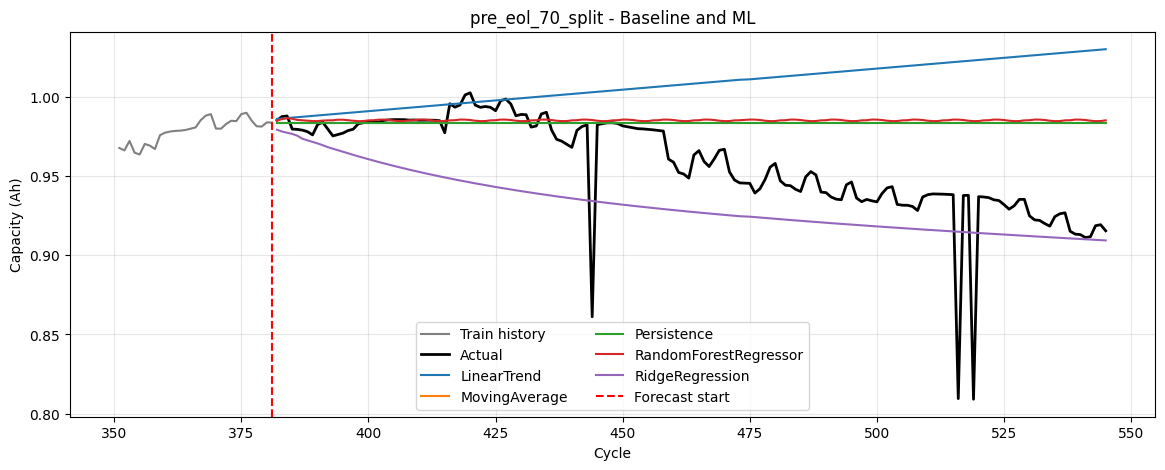

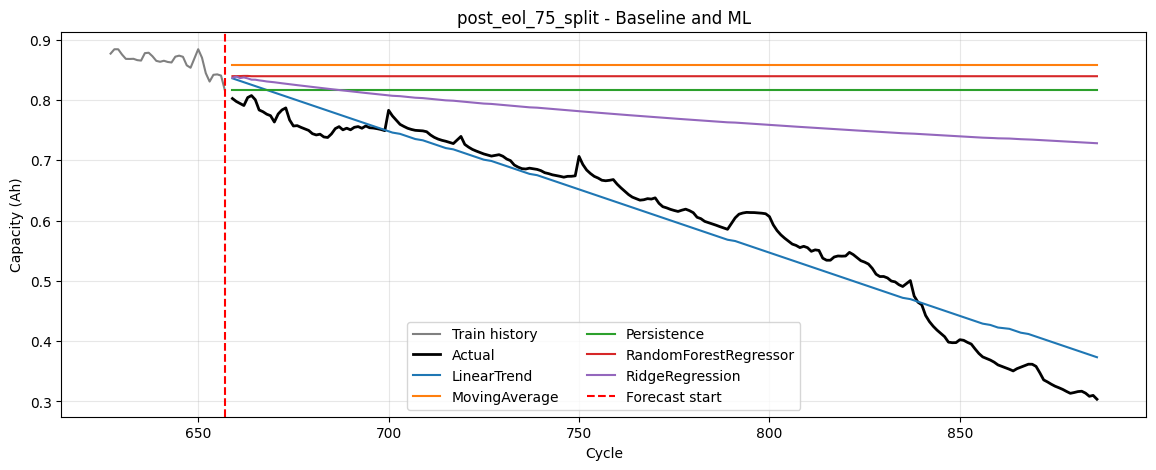

In [74]:
comparison_forecasts = pd.concat(
    [baseline_forecasts, ml_forecasts],
    ignore_index=True,
)

for experiment_name in EXPERIMENTS:
    train_df, test_df = make_experiment_split(
        series_df,
        experiment_name,
    )

    plot_df = comparison_forecasts.loc[
        comparison_forecasts["experiment_name"]
        == experiment_name
    ]

    plt.figure(figsize=(14, 5))

    plt.plot(
        train_df.tail(30)["cycle"],
        train_df.tail(30)["capacity_ah"],
        color="gray",
        label="Train history",
    )

    plt.plot(
        test_df["cycle"],
        test_df["capacity_ah"],
        color="black",
        linewidth=2,
        label="Actual",
    )

    for model_name, group in plot_df.groupby("model_name"):
        plt.plot(
            group["cycle"],
            group["y_pred_capacity"],
            label=model_name,
        )

    plt.axvline(
        train_df["cycle"].max(),
        color="red",
        linestyle="--",
        label="Forecast start",
    )

    plt.title(f"{experiment_name} - Baseline and ML")
    plt.xlabel("Cycle")
    plt.ylabel("Capacity (Ah)")
    plt.grid(alpha=0.3)
    plt.legend(ncol=2)
    plt.show()

In [75]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

ml_forecasts.to_csv(
    ML_FORECAST_CSV,
    index=False,
)
ml_forecasts.to_parquet(
    ML_FORECAST_PARQUET,
    index=False,
)
ml_metrics.to_csv(
    ML_METRICS_CSV,
    index=False,
)

csv_check = pd.read_csv(ML_FORECAST_CSV)
parquet_check = pd.read_parquet(ML_FORECAST_PARQUET)
metrics_check = pd.read_csv(ML_METRICS_CSV)

assert csv_check.shape == parquet_check.shape
assert list(csv_check.columns) == list(parquet_check.columns)
assert metrics_check.shape == (4, 12)

print("ML forecast:", csv_check.shape)
print("ML metrics:", metrics_check.shape)
print("저장 위치:", OUTPUT_DIR)

ML forecast: (760, 14)
ML metrics: (4, 12)
저장 위치: /Users/namduhus/workplace/02_TimeSeries_Model_Project/Battery_TimeSeries_Analysis/outputs


### 06-1 Ridge / RandomForest 결과

| Experiment | Model | Capacity MAE | Capacity RMSE | Capacity sMAPE |
| --- | --- | ---: | ---: | ---: |
| `pre_eol_70_split` | `RidgeRegression` | 0.028597 | 0.033449 | 3.022726 |
| `pre_eol_70_split` | `RandomForestRegressor` | 0.029467 | 0.041368 | 3.081939 |
| `post_eol_75_split` | `RidgeRegression` | 0.171519 | 0.206790 | 27.658039 |
| `post_eol_75_split` | `RandomForestRegressor` | 0.236162 | 0.276644 | 35.270356 |

#### 결과 해석

Pre-EOL에서는 `RidgeRegression`이 두 ML 모델 중 가장 낮은 MAE를 기록했습니다. 전체 baseline까지 포함하면 `MovingAverage`의 MAE 0.028366이 가장 낮으며, Ridge와의 차이는 약 0.000231 Ah로 작습니다. 따라서 Pre-EOL에서는 복잡한 ML 모델이 단순 baseline을 뚜렷하게 개선하지 못했습니다.

Post-EOL stress test에서도 Ridge가 RandomForest보다 낮은 오차를 기록했습니다. Ridge는 cycle과 lag/rolling feature의 선형 관계를 이용해 감소 추세를 외삽할 수 있지만, RandomForest는 학습 범위를 벗어난 장기 감소 추세를 외삽하기 어렵습니다.

다만 Post-EOL 전체 모델 중에서는 05번의 `LinearTrend`가 MAE 0.030896으로 가장 우수합니다. 현재 분할에서는 최근 20개 cycle의 단순 선형 기울기가 장기 열화 추세와 잘 맞았으며, ML 모델이 항상 baseline보다 우수하지 않다는 점을 보여줍니다.

#### 검증 결과

- ML forecast는 760행이며, 두 실험과 두 모델이 모두 포함되어 있습니다.
- ML metric은 4행입니다.
- 실제 test capacity를 재귀 feature에 사용하지 않았습니다.
- 음수와 결측 예측값 및 중복된 예측 key가 없습니다.
- CSV와 Parquet의 shape과 컬럼 구성이 일치합니다.

06-1 결과는 장기 terminal split 기준이며, 최종 모델 평가는 이후 10, 20, 30 cycle 단기 rolling 평가를 함께 사용해야 합니다.

## 06-2 TimesFM

In [76]:
import torch
import timesfm

torch.set_float32_matmul_precision("high")

TIMESFM_MODEL_ID = "google/timesfm-2.5-200m-pytorch"
TIMESFM_MODEL_NAME = "TimesFM_2p5_200M"
TIMESFM_MODEL_FAMILY = "foundation_model"

TIMESFM_FORECAST_CSV = (
    OUTPUT_DIR / "timesfm_capacity_forecasts.csv"
)
TIMESFM_FORECAST_PARQUET = (
    OUTPUT_DIR / "timesfm_capacity_forecasts.parquet"
)
TIMESFM_METRICS_CSV = (
    OUTPUT_DIR / "timesfm_capacity_metrics.csv"
)

In [77]:
timesfm_model = (
    timesfm.TimesFM_2p5_200M_torch
    .from_pretrained(TIMESFM_MODEL_ID)
)

timesfm_model.compile(
    timesfm.ForecastConfig(
        max_context=1024, # 모델에 입력할 수 있는 과거 시계열의 최대 길이
        max_horizon=256, # 한 번에 예측할 수 있는 미래 길이
        normalize_inputs=True, # 입력 시계열을 모델 내부에서 정규화한 후 예측하고, 결과를 원래 scale로 복원
        per_core_batch_size=1, # device/core에서 동시에 처리할 시계열 개수
        use_continuous_quantile_head=True, # 점 예측뿐 아니라 quantile 예측도 활성화
        force_flip_invariance=True,
        infer_is_positive=True,
        fix_quantile_crossing=True,
    )
)

print("TimesFM model is ready.")

TimesFM model is ready.


In [78]:
timesfm_forecast_frames = []
timesfm_metric_frames = []

for experiment_name in EXPERIMENTS:
    train_df, test_df = make_experiment_split(
        series_df,
        experiment_name,
    )

    horizon = len(test_df)
    assert horizon <= 256

    train_values = (
        train_df[PRIMARY_TARGET]
        .to_numpy(dtype=np.float32)
    )

    # TimesFM에는 train 시계열만 전달합니다.
    point_forecast, quantile_forecast = (
        timesfm_model.forecast(
            horizon=horizon,
            inputs=[train_values],
        )
    )

    raw_predictions = (
        point_forecast[0, :horizon]
        .astype(float)
    )

    predictions = np.clip(
        raw_predictions,
        a_min=0.0,
        a_max=None,
    )

    forecast_df = make_forecast_frame(
        experiment_name=experiment_name,
        model_name=TIMESFM_MODEL_NAME,
        train_df=train_df,
        test_df=test_df,
        raw_predictions=raw_predictions,
        predictions=predictions,
        model_family=TIMESFM_MODEL_FAMILY,
    )

    quantiles = quantile_forecast[0, :horizon]

    assert quantiles.ndim == 2
    assert quantiles.shape[0] == horizon
    assert quantiles.shape[1] >= 10

    # TimesFM 채널 1, 5, 9는 p10, p50, p90입니다.
    capacity_q10 = np.clip(quantiles[:, 1], 0.0, None)
    capacity_q50 = np.clip(quantiles[:, 5], 0.0, None)
    capacity_q90 = np.clip(quantiles[:, 9], 0.0, None)

    forecast_df["y_pred_capacity_q10"] = capacity_q10
    forecast_df["y_pred_capacity_q50"] = capacity_q50
    forecast_df["y_pred_capacity_q90"] = capacity_q90

    forecast_df["y_pred_soh_q10"] = (
        capacity_q10 / INITIAL_CAPACITY
    )
    forecast_df["y_pred_soh_q50"] = (
        capacity_q50 / INITIAL_CAPACITY
    )
    forecast_df["y_pred_soh_q90"] = (
        capacity_q90 / INITIAL_CAPACITY
    )

    timesfm_forecast_frames.append(forecast_df)
    timesfm_metric_frames.append(
        make_metric_frame(forecast_df)
    )

timesfm_forecasts = pd.concat(
    timesfm_forecast_frames,
    ignore_index=True,
)

timesfm_metrics = pd.concat(
    timesfm_metric_frames,
    ignore_index=True,
).sort_values(
    ["experiment_name", "capacity_mae"]
).reset_index(drop=True)

display(timesfm_metrics)

,experiment_name,model_family,primary_target,model_name,capacity_mae,capacity_rmse,capacity_smape,soh_mae,soh_rmse,soh_smape,n,train_end_cycle
0,post_eol_75_split,foundation_model,capacity_ah,TimesFM_2p5_200M,0.217453,0.254551,33.176390,0.191349,0.223993,33.176390,217,657
1,pre_eol_70_split,foundation_model,capacity_ah,TimesFM_2p5_200M,0.029407,0.041170,3.075939,0.025877,0.036228,3.075939,163,381


In [79]:
assert timesfm_forecasts.shape == (380, 20)
assert timesfm_metrics.shape == (2, 12)

assert set(timesfm_forecasts["model_family"]) == {
    "foundation_model"
}

assert (
    timesfm_forecasts["y_pred_capacity_q10"]
    <= timesfm_forecasts["y_pred_capacity_q50"]
).all()

assert (
    timesfm_forecasts["y_pred_capacity_q50"]
    <= timesfm_forecasts["y_pred_capacity_q90"]
).all()

assert (timesfm_forecasts["y_pred_capacity"] >= 0).all()
assert not timesfm_forecasts.isna().any().any()

assert not timesfm_forecasts.duplicated(
    ["experiment_name", "model_name", "cycle"]
).any()

assert np.allclose(
    timesfm_forecasts["y_pred_soh"],
    (
        timesfm_forecasts["y_pred_capacity"]
        / timesfm_forecasts["initial_capacity"]
    ),
)

# Baseline과 동일한 cycle 및 실제값인지 확인합니다.
baseline_actual = (
    baseline_forecasts[
        ["experiment_name", "cycle", "y_true_capacity"]
    ]
    .drop_duplicates()
    .reset_index(drop=True)
)

timesfm_actual = (
    timesfm_forecasts[
        ["experiment_name", "cycle", "y_true_capacity"]
    ]
    .drop_duplicates()
    .reset_index(drop=True)
)

pd.testing.assert_frame_equal(
    baseline_actual,
    timesfm_actual,
    check_dtype=False,
)

print("TimesFM validation passed.")

TimesFM validation passed.


In [80]:
# 불확실성 구간 진단

quantile_diagnostics = []

for experiment_name, group in timesfm_forecasts.groupby(
    "experiment_name"
):
    covered = (
        (group["y_true_capacity"] >= group["y_pred_capacity_q10"])
        & (group["y_true_capacity"] <= group["y_pred_capacity_q90"])
    )

    interval_width = (
        group["y_pred_capacity_q90"]
        - group["y_pred_capacity_q10"]
    )

    quantile_diagnostics.append(
        {
            "experiment_name": experiment_name,
            "p10_p90_coverage": covered.mean(),
            "mean_interval_width": interval_width.mean(),
        }
    )

quantile_diagnostics = pd.DataFrame(
    quantile_diagnostics
)

display(quantile_diagnostics)

,experiment_name,p10_p90_coverage,mean_interval_width
0,post_eol_75_split,0.004608,0.195360
1,pre_eol_70_split,0.558282,0.073964


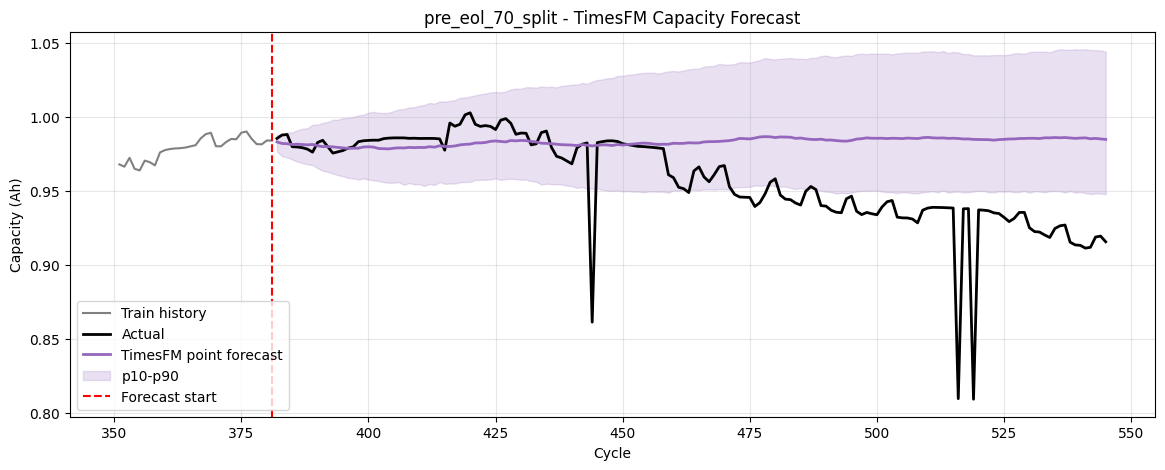

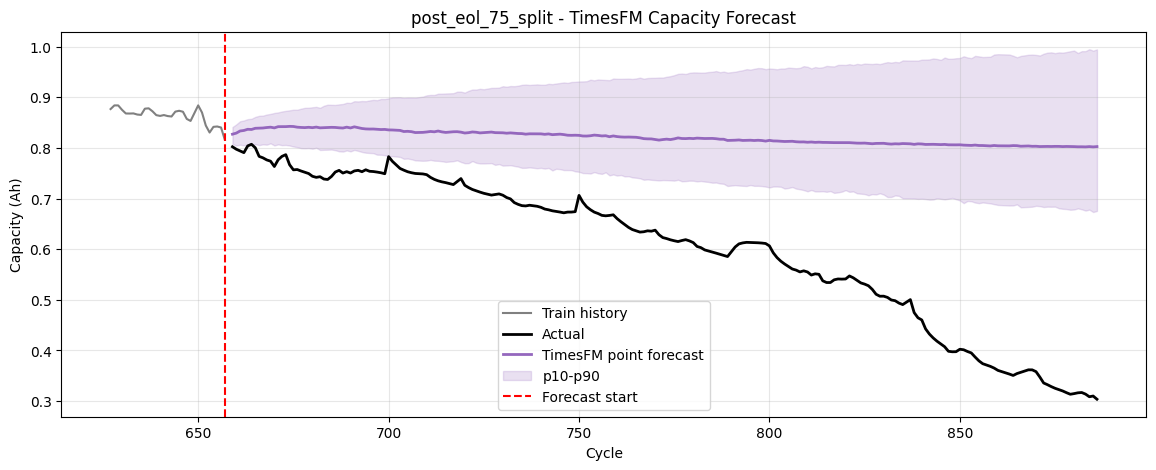

In [81]:
for experiment_name in EXPERIMENTS:
    train_df, test_df = make_experiment_split(
        series_df,
        experiment_name,
    )

    plot_df = timesfm_forecasts.loc[
        timesfm_forecasts["experiment_name"]
        == experiment_name
    ].sort_values("cycle")

    plt.figure(figsize=(14, 5))

    plt.plot(
        train_df.tail(30)["cycle"],
        train_df.tail(30)["capacity_ah"],
        color="gray",
        label="Train history",
    )

    plt.plot(
        plot_df["cycle"],
        plot_df["y_true_capacity"],
        color="black",
        linewidth=2,
        label="Actual",
    )

    plt.plot(
        plot_df["cycle"],
        plot_df["y_pred_capacity"],
        color="tab:purple",
        linewidth=2,
        label="TimesFM point forecast",
    )

    plt.fill_between(
        plot_df["cycle"],
        plot_df["y_pred_capacity_q10"],
        plot_df["y_pred_capacity_q90"],
        color="tab:purple",
        alpha=0.2,
        label="p10-p90",
    )

    plt.axvline(
        train_df["cycle"].max(),
        color="red",
        linestyle="--",
        label="Forecast start",
    )

    plt.title(f"{experiment_name} - TimesFM Capacity Forecast")
    plt.xlabel("Cycle")
    plt.ylabel("Capacity (Ah)")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()

In [82]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

timesfm_forecasts.to_csv(
    TIMESFM_FORECAST_CSV,
    index=False,
)
timesfm_forecasts.to_parquet(
    TIMESFM_FORECAST_PARQUET,
    index=False,
)
timesfm_metrics.to_csv(
    TIMESFM_METRICS_CSV,
    index=False,
)

csv_check = pd.read_csv(TIMESFM_FORECAST_CSV)
parquet_check = pd.read_parquet(TIMESFM_FORECAST_PARQUET)
metrics_check = pd.read_csv(TIMESFM_METRICS_CSV)

assert csv_check.shape == parquet_check.shape
assert list(csv_check.columns) == list(parquet_check.columns)
assert metrics_check.shape == (2, 12)

comparison_metrics_06_2 = pd.concat(
    [
        baseline_metrics,
        ml_metrics,
        timesfm_metrics,
    ],
    ignore_index=True,
).sort_values(
    ["experiment_name", "capacity_mae"]
).reset_index(drop=True)

display(comparison_metrics_06_2)

print("TimesFM forecast:", csv_check.shape)
print("TimesFM metrics:", metrics_check.shape)

,experiment_name,model_family,primary_target,model_name,capacity_mae,capacity_rmse,capacity_smape,soh_mae,soh_rmse,soh_smape,n,train_end_cycle
0,post_eol_75_split,baseline,capacity_ah,LinearTrend,0.030896,0.036043,6.016708,0.027187,0.031716,6.016708,217,657
1,post_eol_75_split,machine_learning,capacity_ah,RidgeRegression,0.171519,0.206790,27.658039,0.150929,0.181966,27.658039,217,657
2,post_eol_75_split,baseline,capacity_ah,Persistence,0.212946,0.257113,32.591385,0.187382,0.226248,32.591385,217,657
3,post_eol_75_split,foundation_model,capacity_ah,TimesFM_2p5_200M,0.217453,0.254551,33.176390,0.191349,0.223993,33.176390,217,657
4,post_eol_75_split,machine_learning,capacity_ah,RandomForestRegressor,0.236162,0.276644,35.270356,0.207812,0.243434,35.270356,217,657
5,post_eol_75_split,baseline,capacity_ah,MovingAverage,0.255115,0.292993,37.393852,0.224490,0.257820,37.393852,217,657
6,pre_eol_70_split,baseline,capacity_ah,MovingAverage,0.028366,0.040093,2.970140,0.024961,0.035280,2.970140,163,381
7,pre_eol_70_split,machine_learning,capacity_ah,RidgeRegression,0.028597,0.033449,3.022726,0.025164,0.029433,3.022726,163,381
8,pre_eol_70_split,baseline,capacity_ah,Persistence,0.028659,0.040455,2.999884,0.025218,0.035598,2.999884,163,381
9,pre_eol_70_split,foundation_model,capacity_ah,TimesFM_2p5_200M,0.029407,0.041170,3.075939,0.025877,0.036228,3.075939,163,381


TimesFM forecast: (380, 20)
TimesFM metrics: (2, 12)


### 06-2 TimesFM 결과

| Experiment | Capacity MAE | Capacity RMSE | Capacity sMAPE | SoH MAE |
| --- | ---: | ---: | ---: | ---: |
| `pre_eol_70_split` | 0.029407 | 0.041170 | 3.075939 | 0.025877 |
| `post_eol_75_split` | 0.217453 | 0.254551 | 33.176390 | 0.191349 |

#### Point forecast 해석

Pre-EOL에서 TimesFM은 capacity MAE 0.029407을 기록했습니다. 전체 비교에서는 `MovingAverage`, `RidgeRegression`, `Persistence` 다음 순위이며, 가장 우수한 MovingAverage와의 MAE 차이는 약 0.001041 Ah입니다. Zero-shot 모델이 단순 baseline과 비슷한 수준을 보였지만 성능을 개선하지는 못했습니다.

Post-EOL stress test에서는 capacity MAE가 0.217453으로 크게 증가했습니다. TimesFM은 장기적인 급격한 capacity 감소를 충분히 추적하지 못하고 실제 capacity보다 높은 값을 예측했습니다. 전체 모델 중에서는 `LinearTrend`가 MAE 0.030896으로 가장 우수하며, TimesFM은 `Persistence`보다도 소폭 낮은 성능을 보였습니다.

#### Quantile 진단

| Experiment | p10-p90 Coverage | Mean Interval Width |
| --- | ---: | ---: |
| `pre_eol_70_split` | 55.83% | 0.073964 Ah |
| `post_eol_75_split` | 0.46% | 0.195360 Ah |

p10-p90 구간은 명목상 중앙 80% 예측 구간이지만 실제 coverage는 이에 미치지 못했습니다. 특히 Post-EOL 실제값의 99.54%가 p10보다 낮아, 불확실성 구간을 넓혔음에도 급격한 열화를 포함하지 못했습니다. 따라서 현재 TimesFM quantile은 `CS2_35` Post-EOL 구간에서 보정된 신뢰구간으로 해석할 수 없습니다.

#### 검증 결과

- TimesFM forecast는 380행, 20컬럼입니다.
- TimesFM metric은 2행, 12컬럼입니다.
- p10, p50, p90의 순서가 모든 예측에서 유지됩니다.
- 음수, 결측값 및 중복된 예측 key가 없습니다.
- Baseline 및 ML과 동일한 test cycle과 실제 capacity를 사용했습니다.
- CSV와 Parquet의 shape과 컬럼 구성이 일치합니다.

현재 결과는 TimesFM의 zero-shot 장기 terminal forecast입니다. 최종 판단에서는 10, 20, 30 cycle 단기 rolling 평가와 quantile coverage를 함께 비교해야 합니다.

## 06-3 Chronos / NeuralForecast추가

In [99]:
from chronos import ChronosBoltPipeline
from neuralforecast import NeuralForecast
from neuralforecast.losses.pytorch import MQLoss
from neuralforecast.models import NHITS, PatchTST

CHRONOS_MODEL_ID = "amazon/chronos-bolt-base"
CHRONOS_MODEL_NAME = "ChronosBolt_Base"
CHRONOS_MODEL_FAMILY = "foundation_model"

NF_MODEL_NAMES = ["NHITS", "PatchTST"]
NF_MODEL_FAMILY = "deep_learning"
NF_INPUT_SIZE = 32
NF_MAX_STEPS = 300
NF_RANDOM_SEED = 42

CHRONOS_FORECAST_CSV = OUTPUT_DIR / "chronos_capacity_forecasts.csv"
CHRONOS_FORECAST_PARQUET = OUTPUT_DIR / "chronos_capacity_forecasts.parquet"
CHRONOS_METRICS_CSV = OUTPUT_DIR / "chronos_capacity_metrics.csv"

NF_FORECAST_CSV = OUTPUT_DIR / "neuralforecast_capacity_forecasts.csv"
NF_FORECAST_PARQUET = OUTPUT_DIR / "neuralforecast_capacity_forecasts.parquet"
NF_METRICS_CSV = OUTPUT_DIR / "neuralforecast_capacity_metrics.csv"

MODEL_FORECAST_CSV = OUTPUT_DIR / "model_capacity_forecasts_all.csv"
MODEL_FORECAST_PARQUET = OUTPUT_DIR / "model_capacity_forecasts_all.parquet"
MODEL_METRICS_CSV = OUTPUT_DIR / "model_capacity_metrics_all.csv"

QUANTILE_COLUMNS = [
    "y_pred_capacity_q10",
    "y_pred_capacity_q50",
    "y_pred_capacity_q90",
    "y_pred_soh_q10",
    "y_pred_soh_q50",
    "y_pred_soh_q90",
]


def normalize_quantiles(q10, q50, q90):
    q10 = np.clip(q10, 0.0, None)
    q50 = np.clip(q50, 0.0, None)
    q90 = np.clip(q90, 0.0, None)

    q10 = np.minimum(q10, q50)
    q90 = np.maximum(q90, q50)

    return q10, q50, q90


def add_quantile_columns(forecast_df, q10, q50, q90):
    forecast_df["y_pred_capacity_q10"] = q10
    forecast_df["y_pred_capacity_q50"] = q50
    forecast_df["y_pred_capacity_q90"] = q90

    forecast_df["y_pred_soh_q10"] = q10 / INITIAL_CAPACITY
    forecast_df["y_pred_soh_q50"] = q50 / INITIAL_CAPACITY
    forecast_df["y_pred_soh_q90"] = q90 / INITIAL_CAPACITY

    return forecast_df

In [100]:
chronos_pipeline = ChronosBoltPipeline.from_pretrained(
    CHRONOS_MODEL_ID,
    device_map="cpu",
)

chronos_quantiles = [
    float(value)
    for value in chronos_pipeline.quantiles
]

Q10_INDEX = chronos_quantiles.index(0.1)
Q50_INDEX = chronos_quantiles.index(0.5)
Q90_INDEX = chronos_quantiles.index(0.9)

print("Chronos model:", CHRONOS_MODEL_ID)
print("Quantiles:", chronos_quantiles)

Loading weights: 100%|██████████| 269/269 [00:00<00:00, 17095.74it/s]

Chronos model: amazon/chronos-bolt-base
Quantiles: [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]


In [101]:
# 2. Chronos-Bolt 실행
chronos_forecast_frames = []
chronos_metric_frames = []

for experiment_name in EXPERIMENTS:
    train_df, test_df = make_experiment_split(
        series_df,
        experiment_name,
    )

    horizon = len(test_df)

    context = [
        torch.tensor(
            train_df[PRIMARY_TARGET].to_numpy(np.float32),
            dtype=torch.float32,
        )
    ]

    quantile_forecast = chronos_pipeline.predict(
        context,
        prediction_length=horizon,
        limit_prediction_length=False,
    )

    quantiles = (
        quantile_forecast[0]
        .detach()
        .cpu()
        .numpy()
    )

    assert quantiles.shape == (
        len(chronos_quantiles),
        horizon,
    )

    raw_q10 = quantiles[Q10_INDEX]
    raw_q50 = quantiles[Q50_INDEX]
    raw_q90 = quantiles[Q90_INDEX]

    q10, q50, q90 = normalize_quantiles(
        raw_q10,
        raw_q50,
        raw_q90,
    )

    forecast_df = make_forecast_frame(
        experiment_name=experiment_name,
        model_name=CHRONOS_MODEL_NAME,
        train_df=train_df,
        test_df=test_df,
        raw_predictions=raw_q50,
        predictions=q50,
        model_family=CHRONOS_MODEL_FAMILY,
    )

    forecast_df = add_quantile_columns(
        forecast_df,
        q10,
        q50,
        q90,
    )

    chronos_forecast_frames.append(forecast_df)
    chronos_metric_frames.append(
        make_metric_frame(forecast_df)
    )

chronos_forecasts = pd.concat(
    chronos_forecast_frames,
    ignore_index=True,
).reindex(columns=timesfm_forecasts.columns)

chronos_metrics = pd.concat(
    chronos_metric_frames,
    ignore_index=True,
).reindex(columns=baseline_metrics.columns)

display(chronos_metrics)

/Users/namduhus/workplace/02_TimeSeries_Model_Project/.venv/lib/python3.13/site-packages/chronos/chronos_bolt.py:546: UserWarning: We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
  warnings.warn(msg)
/Users/namduhus/workplace/02_TimeSeries_Model_Project/.venv/lib/python3.13/site-packages/chronos/chronos_bolt.py:546: UserWarning: We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
  warnings.warn(msg)


,experiment_name,model_family,primary_target,model_name,capacity_mae,capacity_rmse,capacity_smape,soh_mae,soh_rmse,soh_smape,n,train_end_cycle
0,pre_eol_70_split,machine_learning,capacity_ah,ChronosBolt_Base,0.023762,0.032068,2.498919,0.020909,0.028219,2.498919,163,381
1,post_eol_75_split,machine_learning,capacity_ah,ChronosBolt_Base,0.233072,0.271167,34.945976,0.205093,0.238614,34.945980,217,657


In [102]:
# 3. NeuralForecast 실행
neuralforecast_frames = []
neuralforecast_metric_frames = []

for experiment_name in EXPERIMENTS:
    train_df, test_df = make_experiment_split(
        series_df,
        experiment_name,
    )

    horizon = len(test_df)

    assert len(train_df) >= NF_INPUT_SIZE + horizon

    # 제외 cycle 이후의 관측 순서를 연속 시간축으로 사용합니다.
    nf_train_df = pd.DataFrame(
        {
            "unique_id": train_df["cell_id"].astype(str).to_numpy(),
            "ds": np.arange(len(train_df)),
            "y": train_df[PRIMARY_TARGET].to_numpy(np.float32),
        }
    )

    models = [
        NHITS(
            h=horizon,
            input_size=NF_INPUT_SIZE,
            loss=MQLoss(level=[80]),
            max_steps=NF_MAX_STEPS,
            scaler_type="robust",
            random_seed=NF_RANDOM_SEED,
            batch_size=1,
            windows_batch_size=128,
            alias="NHITS",
            logger=False,
            enable_checkpointing=False,
            enable_progress_bar=False,
        ),
        PatchTST(
            h=horizon,
            input_size=NF_INPUT_SIZE,
            loss=MQLoss(level=[80]),
            max_steps=NF_MAX_STEPS,
            scaler_type="robust",
            random_seed=NF_RANDOM_SEED,
            batch_size=1,
            windows_batch_size=128,
            patch_len=8,
            stride=4,
            n_heads=4,
            hidden_size=64,
            linear_hidden_size=128,
            encoder_layers=2,
            alias="PatchTST",
            logger=False,
            enable_checkpointing=False,
            enable_progress_bar=False,
        ),
    ]

    nf = NeuralForecast(models=models, freq=1)

    print(
        f"Training {experiment_name}: "
        f"train={len(train_df)}, horizon={horizon}"
    )

    nf.fit(df=nf_train_df)

    nf_predictions = (
        nf.predict()
        .reset_index(drop=True)
        .sort_values("ds")
        .reset_index(drop=True)
    )

    assert len(nf_predictions) == horizon

    for model_name in NF_MODEL_NAMES:
        raw_q10 = nf_predictions[
            f"{model_name}-lo-80"
        ].to_numpy(float)

        raw_q50 = nf_predictions[
            f"{model_name}-median"
        ].to_numpy(float)

        raw_q90 = nf_predictions[
            f"{model_name}-hi-80"
        ].to_numpy(float)

        q10, q50, q90 = normalize_quantiles(
            raw_q10,
            raw_q50,
            raw_q90,
        )

        forecast_df = make_forecast_frame(
            experiment_name=experiment_name,
            model_name=model_name,
            train_df=train_df,
            test_df=test_df,
            raw_predictions=raw_q50,
            predictions=q50,
            model_family=NF_MODEL_FAMILY,
        )

        forecast_df = add_quantile_columns(
            forecast_df,
            q10,
            q50,
            q90,
        )

        neuralforecast_frames.append(forecast_df)
        neuralforecast_metric_frames.append(
            make_metric_frame(forecast_df)
        )

neuralforecast_forecasts = pd.concat(
    neuralforecast_frames,
    ignore_index=True,
).reindex(columns=timesfm_forecasts.columns)

neuralforecast_metrics = pd.concat(
    neuralforecast_metric_frames,
    ignore_index=True,
).reindex(columns=baseline_metrics.columns)

display(neuralforecast_metrics)

INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (mps), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.callbacks.model_summary:
  | Name         | Type          | Params | Mode 
-------------------------------------------------------
0 | loss         | MQLoss        | 3      | train
1 | padder_train | ConstantPad1d | 0      | train
2 | scaler       | TemporalNorm  | 0      | train
3 | blocks       | ModuleList    | 2.9 M  | train
-------------------------------------------------------
2.9 M     Trainable params
3         Non-trainable params
2.9 M     Total params
11.538    Total estimated model params size (MB)
34        Modules in train mode
0         Modules in eval mode
/Users/namduhus/workplace/02_TimeSeries_Model_Project/.venv/lib/python3.13/site-packages/pytorch_lightning/utilities/_pytree.py:

Training pre_eol_70_split: train=378, horizon=163


INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=300` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (mps), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.callbacks.model_summary:
  | Name         | Type              | Params | Mode 
-----------------------------------------------------------
0 | loss         | MQLoss            | 3      | train
1 | padder_train | ConstantPad1d     | 0      | train
2 | scaler       | TemporalNorm      | 0      | train
3 | model        | PatchTST_backbone | 318 K  | train
-----------------------------------------------------------
318 K     Trainable params
5         Non-trainable params
318 K     Total params
1.276     Total estimated model params size (MB)
65        Modules in train mode
0         Modules in eval mode
/Users/namduhus/workplace/02_TimeSeries_Model_Project/.venv/lib/python3.13/site-packages/pytorch_lightning/utilit

Training post_eol_75_split: train=651, horizon=217


INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=300` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (mps), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.callbacks.model_summary:
  | Name         | Type              | Params | Mode 
-----------------------------------------------------------
0 | loss         | MQLoss            | 3      | train
1 | padder_train | ConstantPad1d     | 0      | train
2 | scaler       | TemporalNorm      | 0      | train
3 | model        | PatchTST_backbone | 401 K  | train
-----------------------------------------------------------
401 K     Trainable params
5         Non-trainable params
402 K     Total params
1.608     Total estimated model params size (MB)
65        Modules in train mode
0         Modules in eval mode
/Users/namduhus/workplace/02_TimeSeries_Model_Project/.venv/lib/python3.13/site-packages/pytorch_lightning/utilit

,experiment_name,model_family,primary_target,model_name,capacity_mae,capacity_rmse,capacity_smape,soh_mae,soh_rmse,soh_smape,n,train_end_cycle
0,pre_eol_70_split,machine_learning,capacity_ah,NHITS,0.020932,0.028294,2.204793,0.018419,0.024897,2.204793,163,381
1,pre_eol_70_split,machine_learning,capacity_ah,PatchTST,0.021095,0.030103,2.223976,0.018562,0.026489,2.223976,163,381
2,post_eol_75_split,machine_learning,capacity_ah,NHITS,0.173413,0.211322,27.905235,0.152596,0.185954,27.905235,217,657
3,post_eol_75_split,machine_learning,capacity_ah,PatchTST,0.207087,0.242335,31.990008,0.182227,0.213244,31.990008,217,657


In [104]:
# 재학습 없이 현재 커널의 모델군 분류를 교정합니다.
chronos_forecasts = chronos_forecasts.copy()
chronos_metrics = chronos_metrics.copy()
neuralforecast_forecasts = neuralforecast_forecasts.copy()
neuralforecast_metrics = neuralforecast_metrics.copy()

chronos_forecasts["model_family"] = CHRONOS_MODEL_FAMILY
chronos_metrics["model_family"] = CHRONOS_MODEL_FAMILY

neuralforecast_forecasts["model_family"] = NF_MODEL_FAMILY
neuralforecast_metrics["model_family"] = NF_MODEL_FAMILY

print(
    chronos_forecasts["model_family"].unique(),
    neuralforecast_forecasts["model_family"].unique(),
)

<ArrowStringArray>
['foundation_model']
Length: 1, dtype: str <ArrowStringArray>
['deep_learning']
Length: 1, dtype: str


In [105]:
probabilistic_forecasts = pd.concat(
    [
        timesfm_forecasts,
        chronos_forecasts,
        neuralforecast_forecasts,
    ],
    ignore_index=True,
)

assert probabilistic_forecasts.shape == (1520, 20)
assert set(chronos_forecasts["model_family"]) == {
    CHRONOS_MODEL_FAMILY
}
assert set(neuralforecast_forecasts["model_family"]) == {
    NF_MODEL_FAMILY
}
assert not probabilistic_forecasts.isna().any().any()
assert (probabilistic_forecasts["y_pred_capacity"] >= 0).all()

assert (
    probabilistic_forecasts["y_pred_capacity_q10"]
    <= probabilistic_forecasts["y_pred_capacity_q50"]
).all()

assert (
    probabilistic_forecasts["y_pred_capacity_q50"]
    <= probabilistic_forecasts["y_pred_capacity_q90"]
).all()

assert not probabilistic_forecasts.duplicated(
    ["experiment_name", "model_name", "cycle"]
).any()

# 모든 모델이 baseline과 같은 test 값을 사용하는지 확인합니다.
reference_actual = (
    baseline_forecasts[
        ["experiment_name", "cycle", "y_true_capacity"]
    ]
    .drop_duplicates()
    .sort_values(["experiment_name", "cycle"])
    .reset_index(drop=True)
)

for model_name, group in probabilistic_forecasts.groupby(
    "model_name"
):
    model_actual = (
        group[
            ["experiment_name", "cycle", "y_true_capacity"]
        ]
        .sort_values(["experiment_name", "cycle"])
        .reset_index(drop=True)
    )

    pd.testing.assert_frame_equal(
        reference_actual,
        model_actual,
        check_dtype=False,
    )

print("Probabilistic forecast validation passed.")

Probabilistic forecast validation passed.


In [106]:
# Quantile coverage

quantile_diagnostics = []

for (
    experiment_name,
    model_name,
), group in probabilistic_forecasts.groupby(
    ["experiment_name", "model_name"]
):
    covered = (
        (group["y_true_capacity"] >= group["y_pred_capacity_q10"])
        & (group["y_true_capacity"] <= group["y_pred_capacity_q90"])
    )

    interval_width = (
        group["y_pred_capacity_q90"]
        - group["y_pred_capacity_q10"]
    )

    quantile_diagnostics.append(
        {
            "experiment_name": experiment_name,
            "model_name": model_name,
            "p10_p90_coverage": covered.mean(),
            "mean_interval_width": interval_width.mean(),
        }
    )

quantile_diagnostics = (
    pd.DataFrame(quantile_diagnostics)
    .sort_values(["experiment_name", "model_name"])
    .reset_index(drop=True)
)

display(quantile_diagnostics)

,experiment_name,model_name,p10_p90_coverage,mean_interval_width
0,post_eol_75_split,ChronosBolt_Base,0.000000,0.077980
1,post_eol_75_split,NHITS,0.000000,0.038066
2,post_eol_75_split,PatchTST,0.000000,0.087582
3,post_eol_75_split,TimesFM_2p5_200M,0.004608,0.195360
4,pre_eol_70_split,ChronosBolt_Base,0.527607,0.042965
5,pre_eol_70_split,NHITS,0.110429,0.006150
6,pre_eol_70_split,PatchTST,0.368098,0.017975
7,pre_eol_70_split,TimesFM_2p5_200M,0.558282,0.073964


In [107]:
chronos_forecasts.to_csv(
    CHRONOS_FORECAST_CSV,
    index=False,
)
chronos_forecasts.to_parquet(
    CHRONOS_FORECAST_PARQUET,
    index=False,
)
chronos_metrics.to_csv(
    CHRONOS_METRICS_CSV,
    index=False,
)

neuralforecast_forecasts.to_csv(
    NF_FORECAST_CSV,
    index=False,
)
neuralforecast_forecasts.to_parquet(
    NF_FORECAST_PARQUET,
    index=False,
)
neuralforecast_metrics.to_csv(
    NF_METRICS_CSV,
    index=False,
)

assert pd.read_csv(
    CHRONOS_FORECAST_CSV
).shape == (380, 20)

assert pd.read_csv(
    NF_FORECAST_CSV
).shape == (760, 20)

print("Chronos forecast:", chronos_forecasts.shape)
print("NeuralForecast:", neuralforecast_forecasts.shape)

Chronos forecast: (380, 20)
NeuralForecast: (760, 20)


In [108]:
# Deterministic 모델은 q50을 point forecast로 기록합니다.
deterministic_forecasts = pd.concat(
    [baseline_forecasts, ml_forecasts],
    ignore_index=True,
)

deterministic_forecasts["y_pred_capacity_q10"] = np.nan
deterministic_forecasts["y_pred_capacity_q50"] = (
    deterministic_forecasts["y_pred_capacity"]
)
deterministic_forecasts["y_pred_capacity_q90"] = np.nan

deterministic_forecasts["y_pred_soh_q10"] = np.nan
deterministic_forecasts["y_pred_soh_q50"] = (
    deterministic_forecasts["y_pred_soh"]
)
deterministic_forecasts["y_pred_soh_q90"] = np.nan

deterministic_forecasts = deterministic_forecasts.reindex(
    columns=timesfm_forecasts.columns
)

all_forecasts = pd.concat(
    [
        deterministic_forecasts,
        timesfm_forecasts,
        chronos_forecasts,
        neuralforecast_forecasts,
    ],
    ignore_index=True,
).sort_values(
    ["experiment_name", "model_name", "cycle"]
).reset_index(drop=True)

all_metrics = pd.concat(
    [
        baseline_metrics,
        ml_metrics,
        timesfm_metrics,
        chronos_metrics,
        neuralforecast_metrics,
    ],
    ignore_index=True,
).sort_values(
    ["experiment_name", "capacity_mae"]
).reset_index(drop=True)

assert all_forecasts.shape == (3420, 20)
assert all_metrics.shape == (18, 12)

expected_model_families = {
    "ChronosBolt_Base": "foundation_model",
    "NHITS": "deep_learning",
    "PatchTST": "deep_learning",
    "TimesFM_2p5_200M": "foundation_model",
}

for model_name, model_family in expected_model_families.items():
    actual_families = set(
        all_forecasts.loc[
            all_forecasts["model_name"] == model_name,
            "model_family",
        ]
    )
    assert actual_families == {model_family}

assert not all_forecasts.duplicated(
    ["experiment_name", "model_name", "cycle"]
).any()

assert all_forecasts.groupby(
    "model_name"
).size().eq(380).all()

all_forecasts.to_csv(
    MODEL_FORECAST_CSV,
    index=False,
)
all_forecasts.to_parquet(
    MODEL_FORECAST_PARQUET,
    index=False,
)
all_metrics.to_csv(
    MODEL_METRICS_CSV,
    index=False,
)

display(all_metrics)

,experiment_name,model_family,primary_target,model_name,capacity_mae,capacity_rmse,capacity_smape,soh_mae,soh_rmse,soh_smape,n,train_end_cycle
0,post_eol_75_split,baseline,capacity_ah,LinearTrend,0.030896,0.036043,6.016708,0.027187,0.031716,6.016708,217,657
1,post_eol_75_split,machine_learning,capacity_ah,RidgeRegression,0.171519,0.206790,27.658039,0.150929,0.181966,27.658039,217,657
2,post_eol_75_split,deep_learning,capacity_ah,NHITS,0.173413,0.211322,27.905235,0.152596,0.185954,27.905235,217,657
3,post_eol_75_split,deep_learning,capacity_ah,PatchTST,0.207087,0.242335,31.990008,0.182227,0.213244,31.990008,217,657
4,post_eol_75_split,baseline,capacity_ah,Persistence,0.212946,0.257113,32.591385,0.187382,0.226248,32.591385,217,657
5,post_eol_75_split,foundation_model,capacity_ah,TimesFM_2p5_200M,0.217453,0.254551,33.176390,0.191349,0.223993,33.176390,217,657
6,post_eol_75_split,foundation_model,capacity_ah,ChronosBolt_Base,0.233072,0.271167,34.945976,0.205093,0.238614,34.945980,217,657
7,post_eol_75_split,machine_learning,capacity_ah,RandomForestRegressor,0.236162,0.276644,35.270356,0.207812,0.243434,35.270356,217,657
8,post_eol_75_split,baseline,capacity_ah,MovingAverage,0.255115,0.292993,37.393852,0.224490,0.257820,37.393852,217,657
9,pre_eol_70_split,deep_learning,capacity_ah,NHITS,0.020932,0.028294,2.204793,0.018419,0.024897,2.204793,163,381


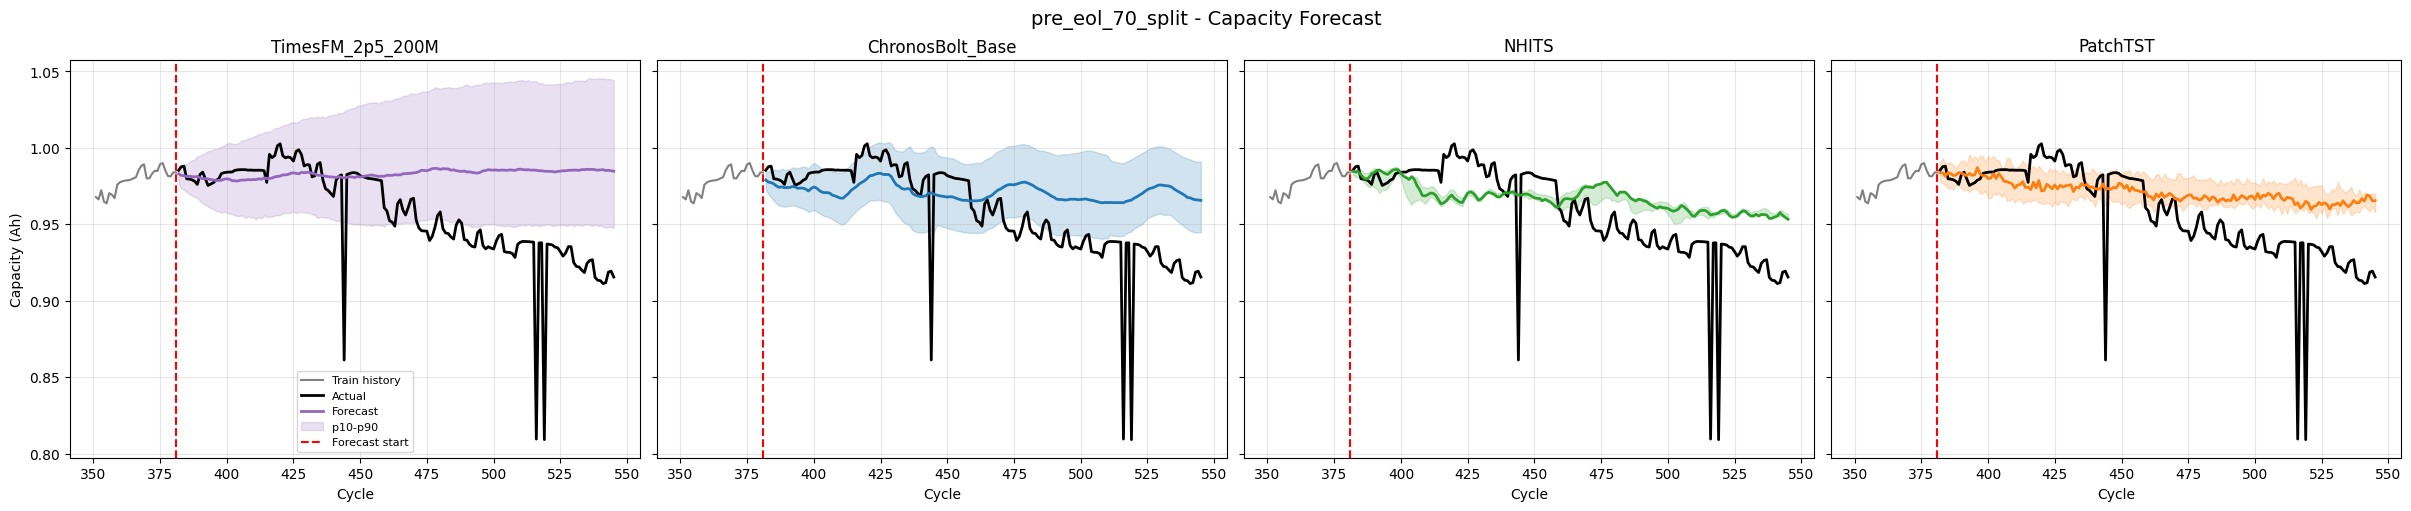

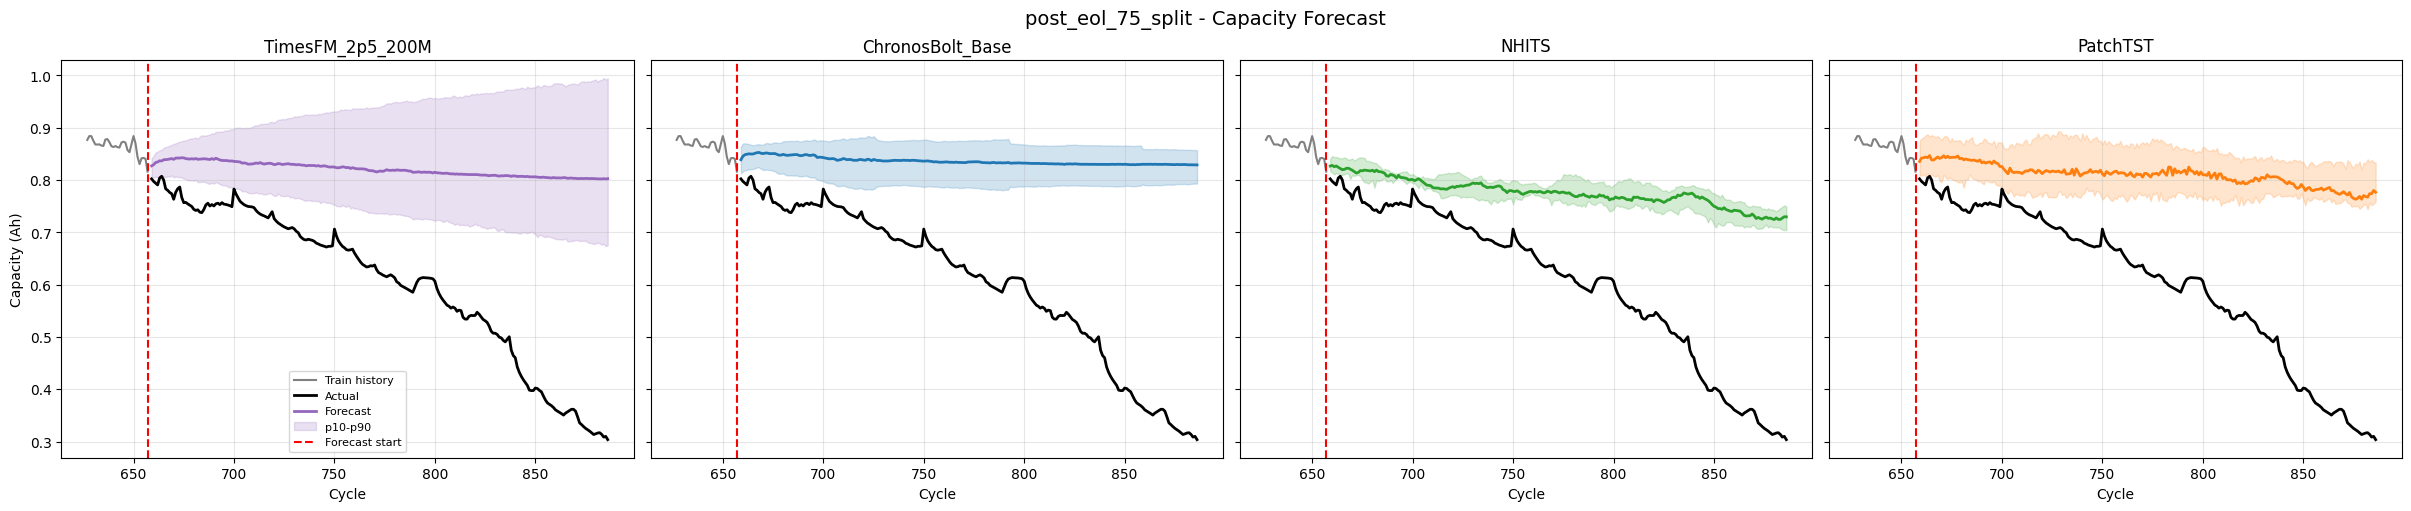

In [109]:
VISUAL_MODELS = [
    TIMESFM_MODEL_NAME,
    CHRONOS_MODEL_NAME,
    *NF_MODEL_NAMES,
]

MODEL_COLORS = {
    TIMESFM_MODEL_NAME: "tab:purple",
    CHRONOS_MODEL_NAME: "tab:blue",
    "NHITS": "tab:green",
    "PatchTST": "tab:orange",
}

for experiment_name in EXPERIMENTS:
    train_df, _ = make_experiment_split(
        series_df,
        experiment_name,
    )

    fig, axes = plt.subplots(
        1,
        len(VISUAL_MODELS),
        figsize=(24, 5),
        sharey=True,
        constrained_layout=True,
    )

    for ax, model_name in zip(axes, VISUAL_MODELS):
        plot_df = all_forecasts.loc[
            (
                all_forecasts["experiment_name"]
                == experiment_name
            )
            & (
                all_forecasts["model_name"]
                == model_name
            )
        ].sort_values("cycle")

        assert not plot_df.empty

        color = MODEL_COLORS[model_name]
        train_tail = train_df.tail(30)

        ax.plot(
            train_tail["cycle"],
            train_tail[PRIMARY_TARGET],
            color="gray",
            label="Train history",
        )
        ax.plot(
            plot_df["cycle"],
            plot_df["y_true_capacity"],
            color="black",
            linewidth=2,
            label="Actual",
        )
        ax.plot(
            plot_df["cycle"],
            plot_df["y_pred_capacity"],
            color=color,
            linewidth=2,
            label="Forecast",
        )
        ax.fill_between(
            plot_df["cycle"],
            plot_df["y_pred_capacity_q10"],
            plot_df["y_pred_capacity_q90"],
            color=color,
            alpha=0.2,
            label="p10-p90",
        )
        ax.axvline(
            train_df["cycle"].max(),
            color="red",
            linestyle="--",
            label="Forecast start",
        )

        ax.set_title(model_name)
        ax.set_xlabel("Cycle")
        ax.grid(alpha=0.3)

    axes[0].set_ylabel("Capacity (Ah)")
    axes[0].legend(fontsize=8)

    fig.suptitle(
        f"{experiment_name} - Capacity Forecast",
        fontsize=14,
    )

    plt.show()

### 06-3 Chronos / NeuralForecast 결과

| Experiment | Model | Capacity MAE | Capacity RMSE | Capacity sMAPE |
| --- | --- | ---: | ---: | ---: |
| `pre_eol_70_split` | `NHITS` | 0.020932 | 0.028294 | 2.204793 |
| `pre_eol_70_split` | `PatchTST` | 0.021095 | 0.030103 | 2.223976 |
| `pre_eol_70_split` | `ChronosBolt_Base` | 0.023762 | 0.032068 | 2.498919 |
| `post_eol_75_split` | `NHITS` | 0.173413 | 0.211322 | 27.905235 |
| `post_eol_75_split` | `PatchTST` | 0.207087 | 0.242335 | 31.990008 |
| `post_eol_75_split` | `ChronosBolt_Base` | 0.233072 | 0.271167 | 34.945976 |

#### Point forecast 해석

Pre-EOL에서는 `NHITS`가 전체 9개 모델 중 가장 낮은 capacity MAE 0.020932를 기록했습니다. 기존 최고 baseline인 MovingAverage의 MAE 0.028366보다 약 26.2% 낮습니다. `PatchTST`와 `ChronosBolt_Base`도 Pre-EOL에서 baseline과 TimesFM보다 낮은 오차를 기록했습니다.

Post-EOL stress test에서는 `LinearTrend`가 MAE 0.030896으로 여전히 전체 1위입니다. 학습 모델 중에서는 Ridge가 MAE 0.171519로 가장 우수하며, NHITS가 0.173413으로 근접했습니다. 장기 급락 구간에서는 복잡한 시계열 모델보다 최근 열화 기울기를 직접 외삽한 단순 baseline이 더 적합했습니다.

Chronos-Bolt는 Pre-EOL에서 TimesFM보다 우수했지만 Post-EOL에서는 MAE 0.233072로 급격한 열화를 추적하지 못했습니다. Foundation model의 zero-shot 결과가 배터리 도메인에 자동으로 일반화되지 않는다는 점을 보여줍니다.

#### p10-p90 Coverage

| Experiment | TimesFM | Chronos-Bolt | NHITS | PatchTST |
| --- | ---: | ---: | ---: | ---: |
| `pre_eol_70_split` | 55.83% | 52.76% | 11.04% | 36.81% |
| `post_eol_75_split` | 0.46% | 0.00% | 0.00% | 0.00% |

명목상 중앙 80% 구간이지만 모든 모델의 coverage가 부족합니다. Post-EOL에서는 Chronos-Bolt, NHITS, PatchTST의 모든 실제값이 p10보다 낮았습니다. 모델이 실제 열화 속도보다 높은 capacity를 예측하므로, 현재 uncertainty band를 정비 위험 판단에 그대로 사용할 수 없습니다.

#### 최종 검증

- Chronos forecast는 380행, 20컬럼입니다.
- NeuralForecast 결과는 760행, 20컬럼입니다.
- 통합 forecast는 3,420행, 20컬럼이며 metric은 18행, 12컬럼입니다.
- Chronos는 `foundation_model`, NHITS와 PatchTST는 `deep_learning`으로 분류했습니다.
- 모든 모델은 동일한 test cycle과 실제 capacity를 사용합니다.
- 음수 point forecast와 중복된 예측 key가 없습니다.
- 통합 CSV와 Parquet의 shape 및 컬럼 구성이 일치합니다.
- Deterministic 모델의 p10/p90 결측값은 uncertainty를 생성하지 않으므로 의도된 값입니다.

다음 단계에서는 10, 20, 30 cycle rolling 평가를 추가하고, 단기 capacity 오차와 EOL crossing 기반 RUL 오차를 함께 비교해야 합니다.